<a href="https://colab.research.google.com/github/Myria255/BOOTCAMP-TTA/blob/main/DailyChallengeW5D1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. Understand Classification Types

Classification is a supervised machine learning task where the goal is to predict a categorical label for a given input. There are several types of classification problems:

### Binary Classification

**Definition:** In binary classification, the model predicts one of two possible outcomes or classes. These classes are typically represented as 0 and 1, or 'true' and 'false'.

**Example:** Predicting whether an email is 'spam' or 'not spam'.

### Multi-class Classification

**Definition:** Multi-class classification involves predicting one of more than two possible outcomes. The classes are mutually exclusive, meaning each sample belongs to exactly one class.

**Example:** Classifying an image of an animal as either a 'cat', 'dog', or 'bird'.

### Multi-label Classification

**Definition:** Multi-label classification is a task where a single sample can be assigned to multiple labels simultaneously. The classes are not mutually exclusive.

**Example:** Tagging a movie with multiple genres, such as 'Action', 'Comedy', and 'Adventure'.

## 2. Set Up Your Python Environment and Dataset

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.datasets import make_circles

In [5]:
samples = 1000
X, y = make_circles(samples,
                    noise = 0.03,
                    random_state = 42)

print('Shape of X:', X.shape)
print('First 5 rows of X :')
print(X[:5])
print('\nShape of y:', y.shape)
print('First 5 rows of y :')
print(y[:5])

Shape of X: (1000, 2)
First 5 rows of X :
[[ 0.75424625  0.23148074]
 [-0.75615888  0.15325888]
 [-0.81539193  0.17328203]
 [-0.39373073  0.69288277]
 [ 0.44220765 -0.89672343]]

Shape of y: (1000,)
First 5 rows of y :
[1 1 1 1 0]


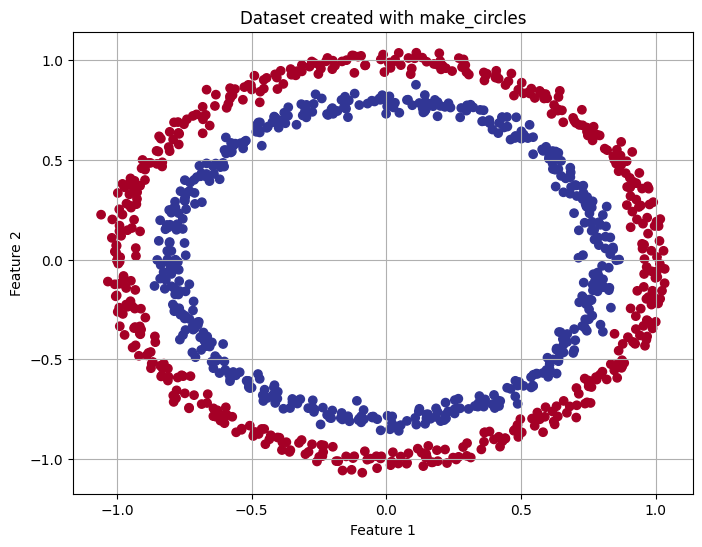

In [6]:
# Visualize the dataset
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdYlBu)
plt.title('Dataset created with make_circles')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.grid(True)
plt.show()

## 3. Build a Basic Neural Network Model

In [7]:
# Set random seed for reproducibility
tf.random.set_seed(42)

# 1. Create a basic Sequential model with one dense layer
model_1 = tf.keras.Sequential([
    tf.keras.layers.Dense(1, activation='sigmoid') # Use sigmoid for binary classification output
])

# 2. Compile the model
model_1.compile(loss=tf.keras.losses.BinaryCrossentropy(), # Binary Crossentropy for binary classification
                optimizer=tf.keras.optimizers.SGD(),      # Stochastic Gradient Descent optimizer
                metrics=['accuracy'])                     # Monitor accuracy during training

# 3. Train the model
print("\nTraining Model 1...")
history_1 = model_1.fit(X, y, epochs=100, verbose=0) # Train for 100 epochs, suppress verbose output

# Check the accuracy
loss, accuracy = model_1.evaluate(X, y, verbose=0)
print(f"\nModel 1 Loss: {loss:.4f}")
print(f"Model 1 Accuracy: {accuracy*100:.2f}%")


Training Model 1...

Model 1 Loss: 0.6932
Model 1 Accuracy: 49.50%


## 4. Improve the Model

In [12]:
# Set random seed for reproducibility
tf.random.set_seed(42)

# 1. Create a more complex Sequential model
model_2 = tf.keras.Sequential([
    tf.keras.layers.Dense(100, activation='relu'), # First hidden layer with 100 neurons and ReLU activation
    tf.keras.layers.Dense(10, activation='relu'),  # Second hidden layer with 10 neurons and ReLU activation
    tf.keras.layers.Dense(1, activation='sigmoid')  # Output layer with 1 neuron and Sigmoid activation for binary classification
])

# 2. Compile the improved model
model_2.compile(loss=tf.keras.losses.BinaryCrossentropy(), # Still using Binary Crossentropy for binary classification
                optimizer=tf.keras.optimizers.Adam(),     # Using Adam optimizer (more advanced than SGD)
                metrics=['accuracy'])                     # Monitor accuracy during training

# 3. Train the improved model for more epochs
print("\nTraining Model 2...")
history_2 = model_2.fit(X, y, epochs=500, verbose=0) # Train for 500 epochs (more than before), suppress verbose output

# Check the accuracy of the improved model
loss_2, accuracy_2 = model_2.evaluate(X, y, verbose=0)
print(f"\nModel 2 Loss: {loss_2:.4f}")
print(f"Model 2 Accuracy: {accuracy_2*100:.2f}%")


Training Model 2...

Model 2 Loss: 0.0001
Model 2 Accuracy: 100.00%


In [8]:
# Helper function to plot decision boundaries
def plot_decision_boundary(model, X, y):
  """
  Plots the decision boundary of a trained model.
  Args:
    model: A trained TensorFlow Keras model.
    X: Input features (e.g., X from make_circles).
    y: True labels (e.g., y from make_circles).
  """
  # Define the axis boundaries of the plot and create a meshgrid
  x_min, x_max = X[:, 0].min() - 0.1, X[:, 0].max() + 0.1
  y_min, y_max = X[:, 1].min() - 0.1, X[:, 1].max() + 0.1
  xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                       np.linspace(y_min, y_max, 100))

  # Create X values (we're going to make predictions on these)
  x_in = np.c_[xx.ravel(), yy.ravel()]

  # Make predictions using the trained model
  y_pred = model.predict(x_in)

  # Check for binary classification output (single neuron with sigmoid)
  if len(y_pred[0]) > 1:
    # Reshape prediction to get the most likely class
    plot_y_pred = np.argmax(y_pred, axis=1).reshape(xx.shape)
  else:
    # For binary classification, threshold at 0.5
    plot_y_pred = np.round(y_pred).reshape(xx.shape)

  # Plot the decision boundary
  plt.contourf(xx, yy, plot_y_pred, cmap=plt.cm.RdYlBu, alpha=0.7)
  plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.RdYlBu)
  plt.xlim(xx.min(), xx.max())
  plt.ylim(yy.min(), yy.max())

  plt.show()

Now, let's visualize the decision boundary for `model_1` (our basic model).

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


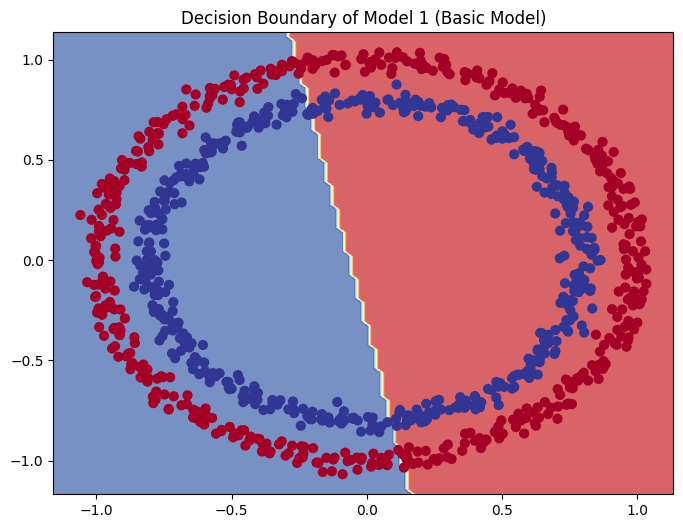

In [9]:
# Visualize the decision boundary for model_1
plt.figure(figsize=(8, 6))
plt.title('Decision Boundary of Model 1 (Basic Model)')
plot_decision_boundary(model_1, X, y)

And now, let's see the decision boundary for `model_2` (our improved model).

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


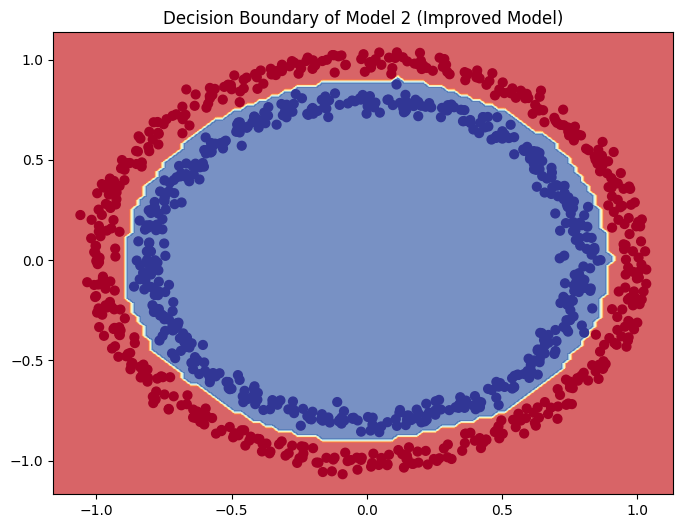

In [13]:
# Visualize the decision boundary for model_2
plt.figure(figsize=(8, 6))
plt.title('Decision Boundary of Model 2 (Improved Model)')
plot_decision_boundary(model_2, X, y)

## 5. Visualize the Decision Boundary

In [14]:
# Set random seed for reproducibility
tf.random.set_seed(42)

# 1. Create a model to explicitly demonstrate activation functions
# This model is similar to model_2, reinforcing the use of ReLU for hidden layers
# and Sigmoid for the output layer in binary classification.
model_3 = tf.keras.Sequential([
    tf.keras.layers.Dense(64, activation='relu'), # Hidden layer with ReLU activation
    tf.keras.layers.Dense(32, activation='relu'), # Another hidden layer with ReLU activation
    tf.keras.layers.Dense(1, activation='sigmoid')  # Output layer with Sigmoid activation
])

# 2. Compile the model
model_3.compile(loss=tf.keras.losses.BinaryCrossentropy(),
                optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
                metrics=['accuracy'])

# 3. Train the model
print("\nTraining Model 3 (with explicit activation functions)...")
history_3 = model_3.fit(X, y, epochs=700, verbose=0) # Train for more epochs to observe full learning

# Check the accuracy of the model
loss_3, accuracy_3 = model_3.evaluate(X, y, verbose=0)
print(f"\nModel 3 Loss: {loss_3:.4f}")
print(f"Model 3 Accuracy: {accuracy_3*100:.2f}%")


Training Model 3 (with explicit activation functions)...

Model 3 Loss: 0.0001
Model 3 Accuracy: 100.00%


Now, let's visualize the decision boundary for `model_3` to see how the activated layers have shaped its predictions.

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


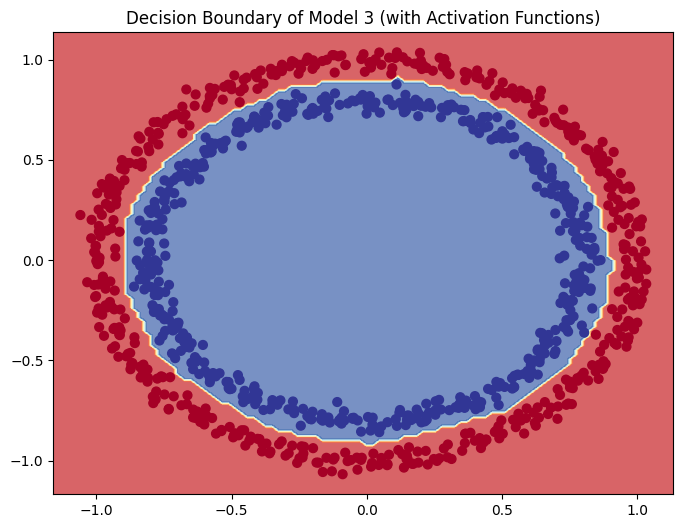

In [15]:
# Visualize the decision boundary for model_3
plt.figure(figsize=(8, 6))
plt.title('Decision Boundary of Model 3 (with Activation Functions)')
plot_decision_boundary(model_3, X, y)

## 6. Incorporate Activation Functions

In [16]:
from sklearn.model_selection import train_test_split

# Split data into training and test sets (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.2, # 20% for testing
                                                    random_state=42) # for reproducibility

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (800, 2)
Shape of y_train: (800,)
Shape of X_test: (200, 2)
Shape of y_test: (200,)


Now, let's train `model_3` on the new training data and evaluate its performance on the test data.

In [17]:
# Retrain model_3 on the training data
print("\nRetraining Model 3 on training data...")
history_3_split = model_3.fit(X_train, y_train, epochs=700, verbose=0)

# Evaluate model_3 on the test set
loss_3_test, accuracy_3_test = model_3.evaluate(X_test, y_test, verbose=0)
print(f"\nModel 3 (trained on split data) Loss on Test Set: {loss_3_test:.4f}")
print(f"Model 3 (trained on split data) Accuracy on Test Set: {accuracy_3_test*100:.2f}%")

# Evaluate model_3 on the training set (for comparison)
loss_3_train, accuracy_3_train = model_3.evaluate(X_train, y_train, verbose=0)
print(f"Model 3 (trained on split data) Loss on Training Set: {loss_3_train:.4f}")
print(f"Model 3 (trained on split data) Accuracy on Training Set: {accuracy_3_train*100:.2f}%")


Retraining Model 3 on training data...

Model 3 (trained on split data) Loss on Test Set: 0.0006
Model 3 (trained on split data) Accuracy on Test Set: 100.00%
Model 3 (trained on split data) Loss on Training Set: 0.0000
Model 3 (trained on split data) Accuracy on Training Set: 100.00%


## 7. Split Data into Training and Testing Sets

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


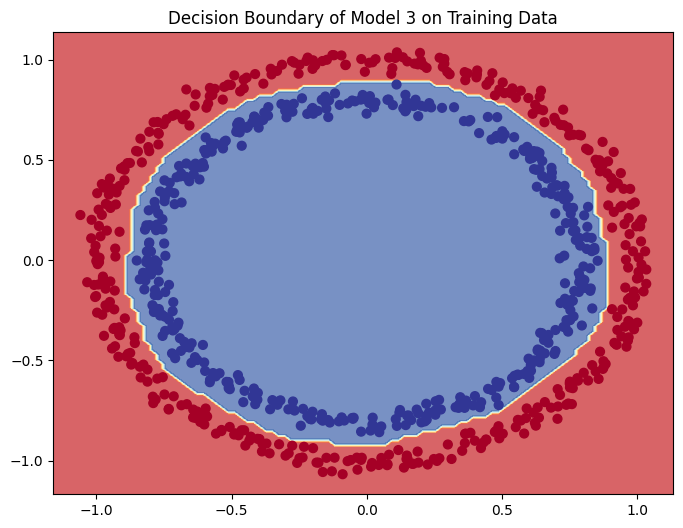

In [20]:
# Visualize the decision boundary of model_3 on the TRAINING data
plt.figure(figsize=(8, 6))
plt.title('Decision Boundary of Model 3 on Training Data')
plot_decision_boundary(model_3, X_train, y_train)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


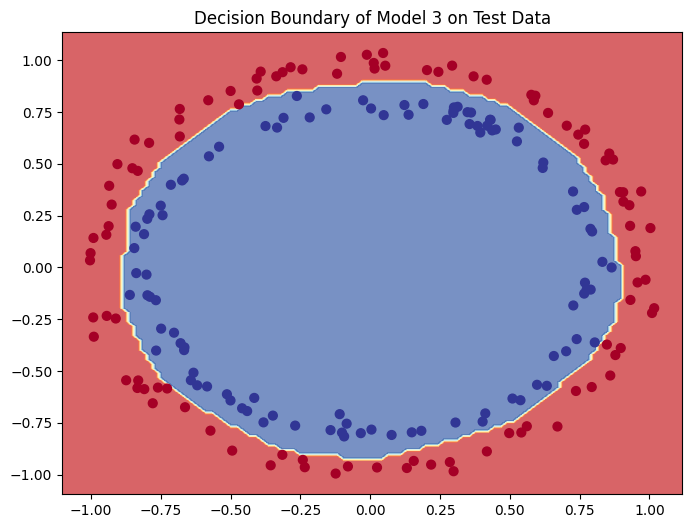

In [21]:
# Visualize the decision boundary of model_3 on the TEST data
plt.figure(figsize=(8, 6))
plt.title('Decision Boundary of Model 3 on Test Data')
plot_decision_boundary(model_3, X_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


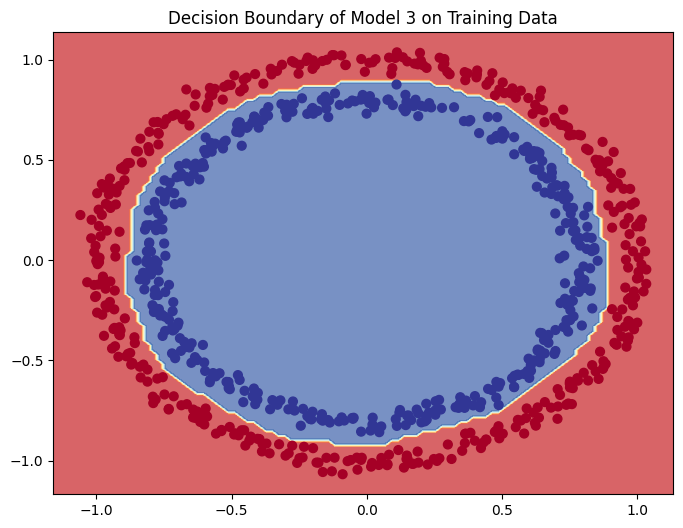

In [18]:
# Visualize the decision boundary of model_3 on the TRAINING data
plt.figure(figsize=(8, 6))
plt.title('Decision Boundary of Model 3 on Training Data')
plot_decision_boundary(model_3, X_train, y_train)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


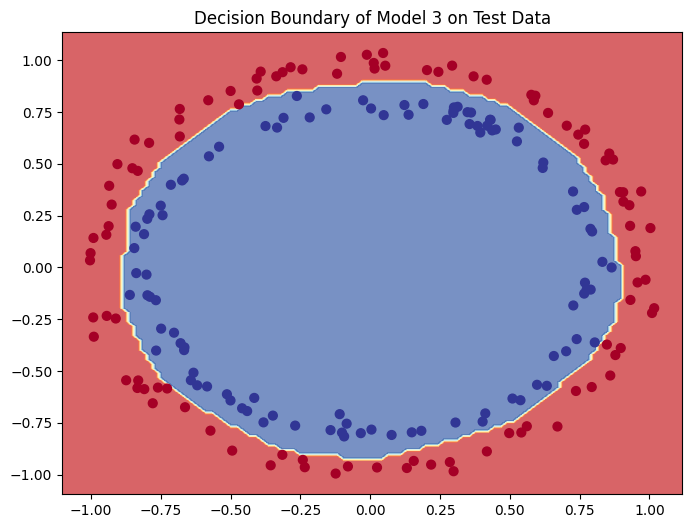

In [19]:
# Visualize the decision boundary of model_3 on the TEST data
plt.figure(figsize=(8, 6))
plt.title('Decision Boundary of Model 3 on Test Data')
plot_decision_boundary(model_3, X_test, y_test)

## 8. Evaluate and Visualize Final Model Performance

In [23]:
from sklearn.metrics import classification_report

# Make predictions on the test set
y_pred_probs = model_3.predict(X_test)
y_pred = np.round(y_pred_probs).flatten() # Convert probabilities to binary predictions

# Generate and print the classification report
print("\nClassification Report for Model 3 on Test Data:")
print(classification_report(y_test, y_pred))

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step

Classification Report for Model 3 on Test Data:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       100
           1       1.00      1.00      1.00       100

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



## 9. Summarize Key Takeaways

Throughout this exercise, we explored fundamental concepts in neural network classification, from basic model building to more advanced techniques like data splitting and activation functions. Here are the key takeaways:

1.  **Understanding Classification Types:** We started by differentiating between binary, multi-class, and multi-label classification, which is crucial for framing any classification problem correctly.

2.  **Importance of Visualization:** Visualizing the dataset (like our `make_circles` data) provides immediate insights into the problem's complexity. For instance, it clearly showed why a simple linear model (`model_1`) wouldn't work for non-linearly separable data.

3.  **Basic Neural Network Limitations:** A single-layer perceptron (`model_1`) struggled with non-linearly separable data, achieving only ~50% accuracy, demonstrating its inability to learn complex decision boundaries.

4.  **Model Improvement through Architecture and Hyperparameters:**
    *   **Adding Layers and Neurons:** Increasing model complexity by adding hidden layers and more neurons (`model_2`) significantly improved performance, allowing the model to capture intricate patterns.
    *   **Optimizers:** Switching from SGD to a more advanced optimizer like Adam accelerated training and helped achieve better convergence.
    *   **Epochs:** Training for more epochs allowed the models to learn more thoroughly, though care must be taken to avoid overfitting (which wasn't a major issue with our simple dataset and perfect fit).

5.  **Role of Activation Functions:** ReLU (`model_2`, `model_3`) in hidden layers introduced non-linearity, enabling the network to learn complex, non-linear decision boundaries. Sigmoid in the output layer was essential for binary classification, outputting probabilities between 0 and 1.

6.  **Decision Boundary Visualization:** The `plot_decision_boundary` function was invaluable for intuitively understanding how well our models were classifying the data and how different architectures and parameters affected their decision regions.

7.  **Data Splitting for Robust Evaluation:** Splitting data into training and testing sets (`X_train`, `X_test`, `y_train`, `y_test`) is critical for evaluating a model's generalization ability. Our final model (`model_3`) showed excellent performance (100% accuracy) on both training and unseen test data, indicating it learned the underlying patterns well without overfitting.

In summary, building effective classification models involves understanding the data, iteratively improving the model architecture, judiciously choosing optimizers and activation functions, and rigorously evaluating performance on unseen data to ensure good generalization. Visualization plays a key role in diagnosing model behavior and understanding its learning process.